In [1]:
from datetime import datetime
import pickle
import os
from multiprocessing import Pool

import numpy as np
import pandas as pd
import lingam
from scipy.stats import kendalltau

import matplotlib.pyplot as plt

np.random.seed(0)

## 仮実装

In [2]:
import itertools
import numpy as np
from sklearn.preprocessing import scale
from sklearn.utils import check_array, check_scalar
from scipy.linalg import pinvh

from lingam import DirectLiNGAM

np.random.seed(0)

class HighDimDirectLiNGAM(DirectLiNGAM):

    def __init__(self, K=4, J=3, **kwargs):
        super().__init__(**kwargs)

        self._K = check_scalar(K, "K", int, min_val=2,include_boundaries="neither")
        self._J = check_scalar(J, "J", int, min_val=1)

    def fit(self, X):
        """Fit the model to X.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data, where ``n_samples`` is the number of samples
            and ``n_features`` is the number of features.

        Returns
        -------
        self : object
            Returns the instance itself.
        """
        # Check parameters
        Y = check_array(X, copy=True)
        # centered
        
        n_features = Y.shape[1]

        # Causal discovery
        theta = [] 
        psi = set(range(n_features))
        # C[z][v]
        C = {}
        
        # 書き換えることのない固定値
        self._Y = Y
        self._alpha = 0.5
        self._sigma = np.cov(self._Y.T, bias=True)
        
        g = []
        
        for z in range(n_features):
            Cz = {}
            stats = []
            
            if z == 0:
                # XXX: z=0ではどのみち前ステップを元にした候補がないので g(0) = 0?
                gz = 0
            else:
                r = theta[-1]
                gz = max([*g, self._alpha * self._T(r, C[z - 1][r], psi)])
            
            for v in psi:
                Cv = self._possible_parents(z, v, C, theta, psi, gz)
                stat = self._T(v, Cv, psi - set([v]))
                
                Cz[v] = Cv
                stats.append((stat, v))
            _, r = min(stats)
            theta.append(r)
            psi.remove(r)
            C[z] = Cz
            g.append(gz)
            
            # XXX: len(psi) == 1だと_T()のV2が空になる。最後は自動的に決まるので終了処理。
            if len(psi) == 1:
                theta.append(psi.pop())
                break

        # XXX: prune?
        
        self._causal_order = theta
        #return self._estimate_adjacency_matrix(X, prior_knowledge=self._Aknw)
        self._adjacency_matrix = np.zeros((len(Y.T), len(Y.T)))
        return self

    def _tau(self, v, u, C):
        if C is None:
            Yvi_C = self._Y[:, v]
        else:
            subcov_inv = np.linalg.pinv(self._sigma[C, :][:, C])
            Bvc = subcov_inv @ self._sigma[C, v]    
            Yvi_C = self._Y[:, v] - self._Y[:, C] @ Bvc

        # XXX: 期待値を平均値で計算
        tau = np.mean(Yvi_C ** (self._K - 1) * self._Y[:, u]) * np.mean(Yvi_C ** 2) \
                                - np.mean(Yvi_C ** self._K) * np.mean(Yvi_C * self._Y[:, u])
        #tau = ((Yvi_C ** (self._K - 1) @ self._Y[:, u])  / len(self._Y)) * ((Yvi_C @ Yvi_C) / len(self._Y)) \
        #                        - np.mean(Yvi_C ** self._K) * ((Yvi_C @ self._Y[:, u]) / len(self._Y))
        return tau

    def _possible_parents(self, z, v, C, theta, psi, gz):
        # XXX: 前ステップのルートrを参照するが最初はないので、親候補なしとした。しきいはなし(0)でいいだろう
        if len(theta) == 0:
            return set()

        Cv = set()
        for p in C[z - 1][v]:
            # Dv
            Dv = set()
            for d in range(z):
                # XXX: Dvに空集合は入るのか？
                for i in range(1, self._J + 1):
                    comb = itertools.combinations(C[d][v] - set([p]), i)
                    Dv |= set(list(comb))

            # 判定
            taus = []
            for C_ in Dv:
                tau = self._tau(v, p, C_)
                taus.append(tau)
                
            # XXX: 条件を満たさなかったり候補なしの時はスキップ
            if len(taus) == 0 or min(taus) <= gz:
                continue
            
            Cv |= set([p])
            
        Cv |= set(theta)
        return Cv

    def _T(self, v, V1, V2, is_T1=True):
        # XXX: V1が空だと空集合の要素を探すことになってしまう。
        # XXX: そこは無視してCは空としてtauの計算はできる。
        # XXX: tauの計算時のYui.Cについて、Cが空のとき残差はデータと同一。
        if len(V1) == 0:
            # XXX: V1Jのループはない。V1Jが空集合なので消してみた。
            taus = []
            for u in V2:
                tau = self._tau(v, u, None)
                taus.append((abs(tau ** (self._K)), u))
            tau, C = max(taus)
            return tau
        
        if self._J <= len(V1):
            V1J = list(itertools.combinations(V1, self._J))
        else:
            V1J = [tuple(V1)]
        
        if is_T1:
            max_taus = []
            for C in V1J:
                taus = []
                for u in V2:
                    tau = self._tau(v, u, C)
                    tau = abs(tau ** self._K)
                    taus.append(tau)
                max_tau = max(taus)
                max_taus.append((max_tau, C))
            tau, C = min(max_taus)
        else:
            min_taus = []
            for u in V2:
                taus = []
                for C in V1J:
                    tau = self._tau(v, u, C)
                    tau = abs(tau ** self._K)
                    taus.append(tau)
                min_tau = min(taus)
                min_taus.append((min_tau, C))
            tau, C = max(min_taus)
        
        return tau

## DAGと誤差変数の生成

In [3]:
# 通常のランダム生成
def make_dag_and_errors(n_nodes, sample_size, J=3, weight=0.5):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(weight, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        # num_paは最低3あるが、例えば2列目の変数の候補は[0]しかない。(1は順序を一意に保つために使う)
        # そのためlen(candidate)との大小関係もチェックが要る。
        pa = np.random.choice(candidates, size=min(num_pa, len(candidates)), replace=False)

        # the corresponding edge weights are set to +-1/5
        dag[v, pa] = np.random.choice([-1/5, 1/5], size=len(pa))

    # The n error terms for variable v are generated by selecting σv ∼ unif(.8, 1) drawing εvi ∼ σvunif(−√3,√3).
    v = np.random.uniform(0.8, 1, size=n_nodes)
    errors = v * np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))

    return dag, errors

# ハブ付き
def make_dag_and_errors_hub(n_nodes, sample_size, J=2):
    # HubGraph
    dag, _ = make_dag_and_errors(n_nodes, sample_size, J=J, weight=0.65)

    # add hubs
    # 非hubノードはいずれかのハブからのエッジを受けること。対角直下は決まっているので手をださないこと。
    for v in np.arange(3, n_nodes):
        # ハブの選択と係数の作成
        coefs = np.zeros(3)
        
        if v == 3:
            # 変数3のみ特別処理。変数2との接続は強制なのでそれ以外から選ぶ。
            index = np.random.choice([0, 1])
        else:
            index = np.random.choice([0, 1, 2])
        
        coefs[index] = np.random.choice([-1/5, 1/5])

        # すでに係数が設定してあれば、そちらを優先する。coefはdag側が0である部分のみ非ゼロになる。
        filter_ = ~np.isclose(dag[v, :3], 0)
        coefs[filter_] = 0
        
        # フィルタしているので足して設定する
        dag[v, :3] += coefs

    # disturbances
    v = np.random.uniform(0.8, 1, size=n_nodes)
    errors = v * np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    
    return dag, errors

### ランダム生成の例
対角の下が強め、ランダムなエッジは小さめになる。

In [4]:
dag, errors = make_dag_and_errors(8, 1000)
pd.DataFrame(dag).style.background_gradient(vmin=-1, vmax=1)

,0,1,2,3,4,5,6,7
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.801382,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-0.200000,0.822947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,-0.200000,0.200000,-0.981831,0.000000,0.000000,0.000000,0.000000,0.000000
4,-0.200000,0.000000,0.200000,-0.696392,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.684121,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,-0.736804,0.000000,0.000000
7,0.000000,0.000000,-0.200000,0.000000,-0.200000,0.000000,0.819961,0.000000


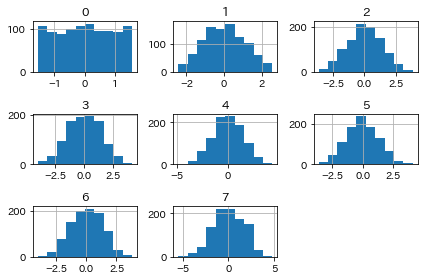

In [5]:
X = errors @ np.linalg.pinv(np.eye(len(dag)) - dag).T
pd.DataFrame(X).hist()
plt.tight_layout()
plt.show()

### ハブつきランダム生成の例

ノード0, 1, 2がハブとなり多くの変数の親となるため、0, 1, 2列は非ゼロの値がいくつか格納される。

In [6]:
dag, errors = make_dag_and_errors_hub(8, 1000)
pd.DataFrame(dag).style.background_gradient(vmin=-1, vmax=1)

,0,1,2,3,4,5,6,7
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.992674,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.200000,0.758404,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,-0.200000,0.994157,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.200000,0.000000,-0.200000,-0.761634,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.200000,-0.200000,0.000000,-0.805072,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.200000,0.000000,0.000000,0.900371,0.000000,0.000000
7,-0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.740583,0.000000


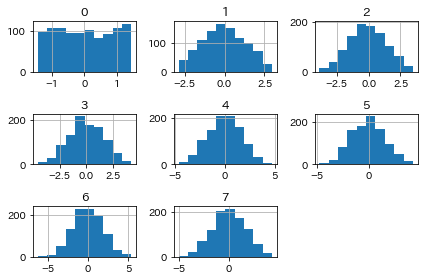

In [7]:
X = errors @ np.linalg.pinv(np.eye(len(dag)) - dag).T
pd.DataFrame(X).hist()
plt.tight_layout()
plt.show()

## 検証関数

In [8]:
def n_list_func_impl(p):
    return [10 * p, 50 * p]

def test_impl(args):
    p, n, i, seed, disable_direct, make_func = args
    
    np.random.seed(seed)
    
    true_order = np.arange(p)

    dag, errors = make_func(p, n)
    X = (np.linalg.pinv(np.eye(p) - dag) @ errors.T).T

    # evals high_im
    high_d_start = datetime.now()

    # XXX:
    #high_d_model = lingam.HighDimDirectLiNGAM()
    #high_d_model = lingam.DirectLiNGAM()
    high_d_model = HighDimDirectLiNGAM()
    high_d_model.fit(X)

    elapse_high_d = (datetime.now() - high_d_start).total_seconds()

    eval_high_d = kendalltau(high_d_model.causal_order_, true_order).statistic

    # evals normal
    if disable_direct:
        eval_normal = None
        elapse_normal = None
    else:
        normal_start = datetime.now()
        
        normal_model = lingam.DirectLiNGAM()
        normal_model.fit(X)
        
        elapse_normal = (datetime.now() - normal_start).total_seconds()

        eval_normal = kendalltau(normal_model.causal_order_, true_order).statistic
        
    print(f"\r{i:8d}", end="")

    return i, eval_high_d, elapse_high_d, eval_normal, elapse_normal
            
def run_test(p_list=None, n_list_func=None, loop_num=500, make_func=None, disable_direct=False, n_cores=24):
    if p_list is None:
        p_list = np.arange(5, 25, 5, dtype=int)

    if n_list_func is None:
        n_list_func = n_list_func_impl

    if make_func is None:
        make_func = make_dag_and_errors
    
    results = {}
    
    for p in p_list:
        for n in n_list_func(p):
            print(f"+p={p:4d}, n={n:4d}")
            
            start = datetime.now()
            
            # テスト実行の引数を辞書に詰め込む
            seeds = np.random.randint(0, high=0xFFFFFFFF, size=loop_num)
            args = {(p, n, i, seed, disable_direct, make_func) for i, seed in enumerate(seeds)}
            
            # マルチプロセスの有効無効
            if n_cores > 0:
                with Pool(n_cores) as pool:
                    result = pool.map(test_impl, args)
            else:
                result = []
                for arg in args:
                    result.append(test_impl(arg))
                
            result = sorted(result, key=lambda e: e[0])
            indices, eval_high_d, elapse_high_d, eval_normal, elapse_normal = np.array(result).T
            
            results[(n, p)] = {
                "high_d": eval_high_d,
                "normal": eval_normal,
                "elapse_high_d": elapse_high_d,
                "elapse_normal": elapse_normal,
            }
            
            elapse = (datetime.now() - start).total_seconds()
            
            print(f"\r-p={p:4d}, n={n:4d}, elapse={elapse:.2f}sec")

    max_p = max(p_list)
    max_n = max(n_list_func(max_p))
    fname = datetime.now().strftime('%Y%m%d%H%M%S') + f"_{max_p}_{max_n}_{loop_num}.bin"

    with open(fname, "wb") as f:
        pickle.dump(results, f)
    print("saved:", fname)
        
    return results

## 低次元時の検証

In [9]:
if True:
    results = run_test(
        # XXX:
        #loop_num=500,
        loop_num=8,
        n_cores=8,
        p_list = np.arange(5, 25, 5, dtype=int),
        n_list_func=n_list_func_impl
    )
else:
    # run_test後に得られるpickleを読み込む場合はこちら
    with open("20240614193139_20_1000_500.bin", "rb") as f:
        results = pickle.load(f)

+p=   5, n=  50
-p=   5, n=  50, elapse=0.13sec
+p=   5, n= 250
-p=   5, n= 250, elapse=0.13sec
+p=  10, n= 100
-p=  10, n= 100, elapse=1.07sec
+p=  10, n= 500
-p=  10, n= 500, elapse=1.71sec
+p=  15, n= 150
-p=  15, n= 150, elapse=14.42sec
+p=  15, n= 750
-p=  15, n= 750, elapse=21.95sec
+p=  20, n= 200
-p=  20, n= 200, elapse=86.54sec
+p=  20, n=1000
-p=  20, n=1000, elapse=168.33sec
saved: 20240620145023_20_1000_8.bin


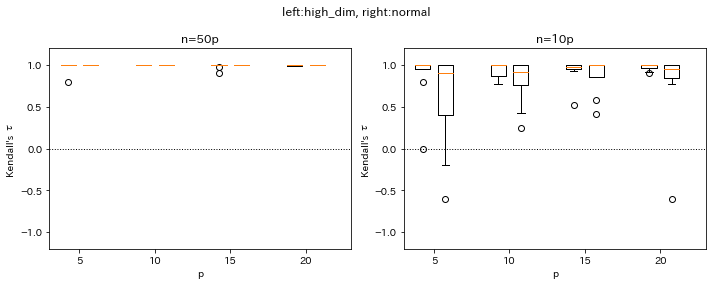

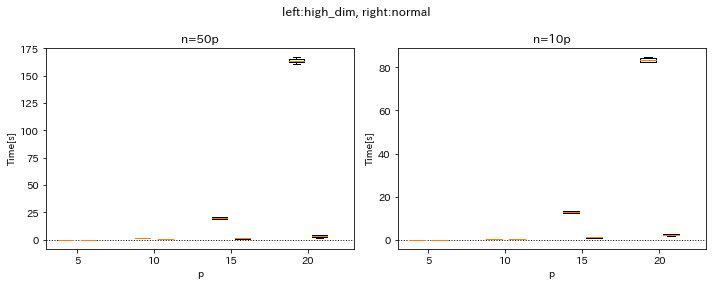

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    ax.boxplot(
        evals["normal"],
        positions=[p + 0.75],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_ylim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[0].set_xlabel("p")
axes[1].set_xlabel("p")
axes[0].set_ylabel("Kendall's τ")
axes[1].set_ylabel("Kendall's τ")
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()
plt.show()


# 時間
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["elapse_high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    ax.boxplot(
        evals["elapse_normal"],
        positions=[p + 0.75],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[0].set_xlabel("p")
axes[1].set_xlabel("p")
axes[0].set_ylabel("Time[s]")
axes[1].set_ylabel("Time[s]")
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()
plt.show()

## 高次元時の検証(ランダム生成)
p>nになるとDirectLiNGAMのLassoLarsICがエラーを出す。

In [ ]:
p_list = [25, 50, 75, 100]#, 150, 200]
n_list_func = lambda p: [int((3 / 4) * p)]

if True:
    results2 = run_test(
        p_list=p_list,
        n_list_func=n_list_func,
        loop_num=1,
        make_func=make_dag_and_errors,
        disable_direct=True,
        n_cores=1,
    )
else:
    with open("20240614193139_20_1000_500.bin", "rb") as f:
        results2 = pickle.load(f)

+p=  25, n=  18


## 高次元時の検証(ハブ付き)

In [ ]:
p_list = [25, 50, 75, 100]#, 150, 200]
n_list_func = lambda p: [int((3 / 4) * p)]

if True:
    results3 = run_test(
        p_list=p_list,
        n_list_func=n_list_func,
        loop_num=1,
        make_func=make_dag_and_errors_hub,
        disable_direct=True,
        n_cores=1,
    )
else:
    with open("20240614193139_20_1000_500.bin", "rb") as f:
        results2 = pickle.load(f)